<a href="https://colab.research.google.com/github/Piyush-47928/DEEP-LEARNING/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Convert MNIST Image files into a tensor of 4 Dimensions (numberof images, height, width, Color channel)
transform = transforms.ToTensor()

In [3]:
#Train Data
train_data = datasets.MNIST(root='/cnn_data', train=True, download=True, transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.54MB/s]


In [4]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [5]:
#Test data
test_data = datasets.MNIST(root='/cnn_data', train=False, download=True, transform=transform)

In [6]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [7]:
# Create a small batch size for images...let's say 10
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [8]:
# Define our CNN Model
# Decribe convolution layer and what it's doing(2 convolution layers)
conv1 = nn.Conv2d(1,6,3,1)
conv2 = nn.Conv2d(6,16,3,1)

In [9]:
#Grab 1 MNIST record/image
for i, (X_train, y_train) in enumerate(train_data):
    break

In [10]:
X_train.shape

torch.Size([1, 28, 28])

In [11]:
x = X_train.view(1,1,28,28)

In [12]:
#Perform our 1st convolution
x = F.relu(conv1(x)) #Rectified Linear Unit for our activation function

In [13]:
# 1 single image, 6 is the filters, 26*26 image
x.shape

torch.Size([1, 6, 26, 26])

In [14]:
# pass through the pooling layer
x = F.max_pool2d(x,2,2) # kernel of 2 and stride of 2

In [15]:
x.shape # 26/2 = 13

torch.Size([1, 6, 13, 13])

In [16]:
# Do our 2nd convolution layer
x = F.relu(conv2(x))

In [17]:
x.shape # Again we didnt set padding so we lose 2 pixels around the outside of the image

torch.Size([1, 16, 11, 11])

In [18]:
#Pooling layer
x = F.max_pool2d(x,2,2)

In [19]:
x.shape # 11/2 = 5.5but we have to roundoff, bcz you can't invent data to round up

torch.Size([1, 16, 5, 5])

In [20]:
# Model class
class ConvolutionalNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,6,3,1)
        self.conv2 = nn.Conv2d(6,16,3,1)
        # Fully Connected layer
        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)

    def forward(self,x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x,2,2) # 2x2 kernel and stride 2
        # Second Pass
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x,2,2) # 2x2 kernel and stride 2

        # Re-view to flatten it out
        x = x.view(-1,5*5*16) # negative one so that we can vary the batch size

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)

In [21]:
#Train model

In [22]:
torch.manual_seed(42)
model = ConvolutionalNeuralNetwork()
model                   #Instance model

ConvolutionalNeuralNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [23]:
# Loss function
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Small learning rate

In [24]:
print(next(iter(train_loader))[0].shape)
print(next(iter(train_loader))[1].shape)
print(next(model.parameters()).device)


torch.Size([64, 1, 28, 28])
torch.Size([64])
cpu


In [25]:
import time
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

start_time = time.time()

epochs = 20
train_losses = []
test_losses = []
train_acc = []
test_acc = []

for epoch in range(epochs):

    # ------------------- TRAIN -------------------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for b, (X_train, y_train) in enumerate(train_loader):

        X_train, y_train = X_train.to(device), y_train.to(device)

        optimizer.zero_grad()

        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(y_pred, 1)
        correct += (predicted == y_train).sum().item()
        total += y_train.size(0)

        if b % 100 == 0:
            print(f"Epoch:{epoch+1} Batch:{b} Loss:{loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    # ------------------- TEST -------------------
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_test, y_test in test_loader:

            X_test, y_test = X_test.to(device), y_test.to(device)

            y_val = model(X_test)
            loss = criterion(y_val, y_test)

            test_loss += loss.item()

            _, predicted = torch.max(y_val, 1)
            correct += (predicted == y_test).sum().item()
            total += y_test.size(0)

    test_loss = test_loss / len(test_loader)
    test_accuracy = 100 * correct / total

    test_losses.append(test_loss)
    test_acc.append(test_accuracy)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_accuracy:.2f}%\n")

# ------------------- TIME -------------------
total_time = (time.time() - start_time) / 60
print(f"Training took: {total_time:.2f} minutes")

Epoch:1 Batch:0 Loss:2.3147
Epoch:1 Batch:100 Loss:0.8898
Epoch:1 Batch:200 Loss:0.2392
Epoch:1 Batch:300 Loss:0.4185
Epoch:1 Batch:400 Loss:0.2437
Epoch:1 Batch:500 Loss:0.2685
Epoch:1 Batch:600 Loss:0.2447
Epoch:1 Batch:700 Loss:0.1004
Epoch:1 Batch:800 Loss:0.1607
Epoch:1 Batch:900 Loss:0.0473

Epoch 1/20
Train Loss: 0.3394 | Train Acc: 89.64%
Test Loss: 0.0995 | Test Acc: 96.78%

Epoch:2 Batch:0 Loss:0.0596
Epoch:2 Batch:100 Loss:0.0613
Epoch:2 Batch:200 Loss:0.0569
Epoch:2 Batch:300 Loss:0.0871
Epoch:2 Batch:400 Loss:0.0754
Epoch:2 Batch:500 Loss:0.0264
Epoch:2 Batch:600 Loss:0.1002
Epoch:2 Batch:700 Loss:0.0271
Epoch:2 Batch:800 Loss:0.0117
Epoch:2 Batch:900 Loss:0.0334

Epoch 2/20
Train Loss: 0.0949 | Train Acc: 96.98%
Test Loss: 0.0602 | Test Acc: 98.08%

Epoch:3 Batch:0 Loss:0.0403
Epoch:3 Batch:100 Loss:0.0567
Epoch:3 Batch:200 Loss:0.0146
Epoch:3 Batch:300 Loss:0.0211
Epoch:3 Batch:400 Loss:0.0764
Epoch:3 Batch:500 Loss:0.0340
Epoch:3 Batch:600 Loss:0.0369
Epoch:3 Batch:700 

Text(0.5, 1.0, 'Loss at epoch')

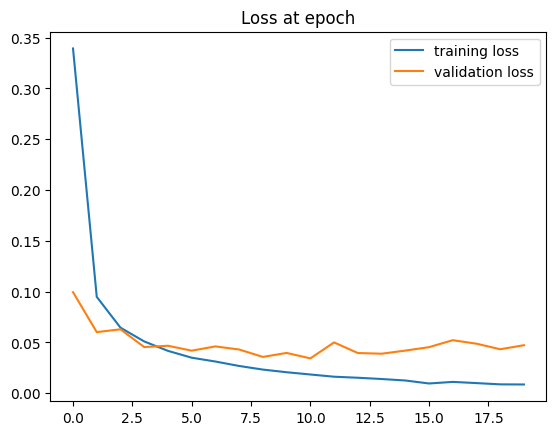

In [26]:
# Graph
plt.plot(train_losses, label='training loss')
plt.plot(test_losses, label='validation loss')
plt.legend()
plt.title('Loss at epoch')